In [272]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from dig4bio.datasets import load_interim_datasets
from dig4bio.utils import get_interim_spectral_cols

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [273]:
interim_dfs = load_interim_datasets()

In [274]:
interim_dfs['anton532'].sample(10)

,200.0,202.0,204.0,206.0,208.0,210.0,212.0,214.0,216.0,218.0,...,3492.0,3494.0,3496.0,3498.0,3500.0,glucose,Na_acetate,Mg_SO4,MSM_present,fold_idx
94,7384.12,7465.24,7293.94,6968.86,6721.58,6604.09,6521.55,6351.46,6190.36,6066.09,...,7264.20,7160.85,6946.38,6887.93,7051.36,0.25787,0.00000,0.000000,0.0,1
139,7441.49,7541.26,7367.09,7027.21,6773.85,6662.60,6579.90,6378.67,6197.97,6084.72,...,6858.90,6772.23,6512.90,6400.79,6585.59,0.29784,1.56128,3.348590,0.0,2
110,7509.44,7582.55,7391.35,7059.56,6818.72,6700.80,6600.45,6412.50,6256.38,6155.90,...,6936.98,6824.79,6598.30,6521.60,6727.28,0.25649,0.74089,3.345560,0.0,2
69,7860.33,7916.66,7694.16,7345.35,7114.89,7019.07,6922.86,6701.67,6511.35,6399.82,...,8400.67,8304.88,8066.38,7957.52,8130.34,0.00000,0.00000,0.000000,0.0,1
65,7849.69,7941.91,7770.26,7430.97,7173.92,7058.71,6978.93,6790.85,6613.51,6489.43,...,8497.55,8383.80,8136.00,8019.07,8193.88,0.00000,0.00000,0.000000,0.0,1
172,7442.88,7501.11,7307.74,6993.21,6760.35,6619.97,6488.82,6317.36,6173.17,6061.19,...,6603.00,6526.09,6310.77,6239.54,6430.95,0.27710,0.69733,1.441180,0.0,3
215,7688.58,7791.58,7609.35,7250.28,6976.60,6852.64,6770.54,6584.53,6424.90,6327.07,...,7050.80,6975.69,6763.97,6682.61,6865.43,4.87666,0.72635,3.073870,0.0,4
47,7855.57,7937.75,7754.15,7431.91,7196.21,7069.05,6947.50,6745.40,6582.47,6474.62,...,8415.91,8343.10,8109.79,7992.89,8171.26,0.00000,0.00000,0.000000,0.0,0
203,7940.08,8006.08,7804.03,7465.26,7229.08,7125.12,7035.05,6836.10,6649.22,6513.61,...,8481.27,8379.86,8156.00,8068.72,8238.05,4.63261,0.69969,0.022235,1.0,3
143,7971.57,8062.91,7887.20,7555.25,7292.73,7138.66,7016.02,6852.81,6712.88,6592.73,...,8569.16,8492.54,8264.25,8160.54,8344.40,6.39311,0.00000,0.024451,1.0,2


In [275]:
device_stats = {}

for device, df in interim_dfs.items():
    spectral_cols = get_interim_spectral_cols(device,df)
    spectral_vals = np.array(spectral_cols, dtype=float)

    device_stats[device]={
        'wavenumber_min'        : spectral_vals.min(),
        'wavenumber_max'        : spectral_vals.max(),
        'wavenumber_count'      : spectral_vals.size,
        'avg_wavenumber_dist'   : (spectral_vals.max()-spectral_vals.min())/spectral_vals.size
    }

for device, stats in device_stats.items():
    print(f'{device:<15}: {stats['wavenumber_min'].round(2):<6} - {stats['wavenumber_max'].round(2):<8} | Count: {stats['wavenumber_count']:<4} | Average Wn: {stats['avg_wavenumber_dist'].round(2)}')

anton532       : 200.0  - 3500.0   | Count: 1651 | Average Wn: 2.0
anton785       : 100.0  - 2300.0   | Count: 1101 | Average Wn: 2.0
kaiser         : -36.3  - 1941.3   | Count: 6593 | Average Wn: 0.3
metrohm        : 202.22 - 3349.39  | Count: 1917 | Average Wn: 1.64
mettler        : 300.0  - 3200.0   | Count: 2901 | Average Wn: 1.0
tec            : 85.0   - 3210.0   | Count: 3126 | Average Wn: 1.0
timegate       : 200.93 - 1997.69  | Count: 511  | Average Wn: 3.52
tornado        : 300.0  - 3300.0   | Count: 3001 | Average Wn: 1.0
transfer_plate : 65.0   - 3348.4   | Count: 2047 | Average Wn: 1.6
96_samples     : 65.0   - 3350.0   | Count: 2048 | Average Wn: 1.6


In [276]:
max_min = max([stats['wavenumber_min'] for stats in device_stats.values()])
min_max = min([stats['wavenumber_max'] for stats in device_stats.values()])

print(f'Smallest shared range: {max_min.round(2)} - {min_max.round(2)}')

## This range seems similar to the fingerprint region

Smallest shared range: 300.0 - 1941.3


In [277]:
fingerprint_region = (300,1800)
fingerprint_grid = np.arange(start = fingerprint_region[0],stop = fingerprint_region[1]+1,step=1)
display(fingerprint_grid)

array([ 300,  301,  302, ..., 1798, 1799, 1800], shape=(1501,))

In [278]:
# np.interp(fingerprint_grid,interim_dfs['anton532'].iloc[0],)
test_df = interim_dfs['timegate']
test_spectral_cols = get_interim_spectral_cols('timegate',test_df)
test_spectral = test_df[test_spectral_cols]
original_data = test_spectral.iloc[0].to_numpy()
display(np.array(test_spectral_cols,dtype='float'))
display(original_data)

array([ 200.925569,  205.066898,  209.205702,  213.34198 ,  217.475732,
        221.606958,  225.735655,  229.861825,  233.985465,  238.106575,
        242.225156,  246.341205,  250.454722,  254.565706,  258.674158,
        262.780075,  266.883458,  270.984306,  275.082618,  279.178393,
        283.271632,  287.362332,  291.450494,  295.536117,  299.6192  ,
        303.699743,  307.777745,  311.853206,  315.926124,  319.9965  ,
        324.064332,  328.12962 ,  332.192364,  336.252562,  340.310215,
        344.365322,  348.417882,  352.467894,  356.515359,  360.560274,
        364.602641,  368.642458,  372.679726,  376.714442,  380.746607,
        384.776221,  388.803282,  392.82779 ,  396.849745,  400.869147,
        404.885994,  408.900286,  412.912023,  416.921204,  420.927829,
        424.931898,  428.933409,  432.932362,  436.928758,  440.922594,
        444.913872,  452.052719,  455.995933,  459.937101,  463.87622 ,
        467.813284,  471.748291,  475.681235,  479.612113,  483.

array([2.53540e-03, 2.42689e-03, 2.32680e-03, 2.24833e-03, 2.10803e-03,
       2.04866e-03, 1.92706e-03, 1.87668e-03, 1.76679e-03, 1.69763e-03,
       1.61327e-03, 1.54059e-03, 1.43603e-03, 1.38720e-03, 1.32440e-03,
       1.27671e-03, 1.25863e-03, 1.19149e-03, 1.12732e-03, 1.08943e-03,
       1.04382e-03, 1.00911e-03, 9.83917e-04, 9.65240e-04, 9.08984e-04,
       8.75432e-04, 8.65906e-04, 8.63413e-04, 8.46283e-04, 8.35781e-04,
       8.27699e-04, 8.20475e-04, 8.16178e-04, 8.04942e-04, 7.96184e-04,
       7.93414e-04, 7.95737e-04, 7.65934e-04, 7.85099e-04, 7.63504e-04,
       7.72070e-04, 7.76049e-04, 7.60365e-04, 7.73727e-04, 7.68117e-04,
       7.69013e-04, 7.80017e-04, 7.75953e-04, 7.50605e-04, 8.05991e-04,
       7.83545e-04, 7.63324e-04, 7.60535e-04, 7.64707e-04, 7.53301e-04,
       7.50113e-04, 7.40676e-04, 7.62772e-04, 7.40024e-04, 7.42553e-04,
       7.62306e-04, 7.27730e-04, 7.17653e-04, 7.09577e-04, 7.02016e-04,
       7.26493e-04, 6.94195e-04, 7.21308e-04, 6.78091e-04, 6.756

In [279]:
new_data = np.interp(fingerprint_grid,np.array(test_spectral_cols,dtype='float'),test_spectral.iloc[0].to_numpy())

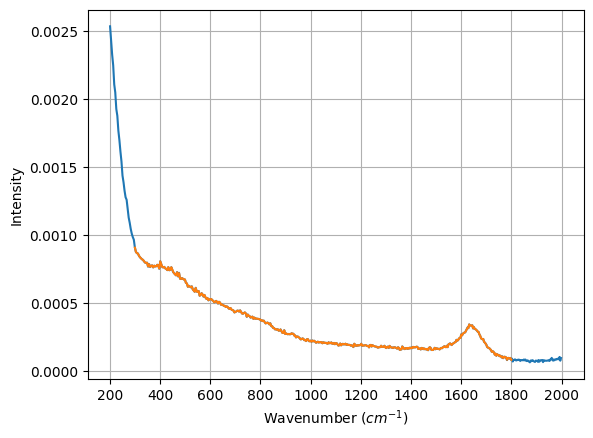

In [280]:
plt.plot(np.array(test_spectral_cols,dtype='float'),original_data)
plt.plot(fingerprint_grid,new_data)
plt.xlabel('Wavenumber $(cm^{-1})$')
plt.ylabel('Intensity')
plt.xticks(np.arange(200,2200,step=200))
plt.grid()
plt.show()

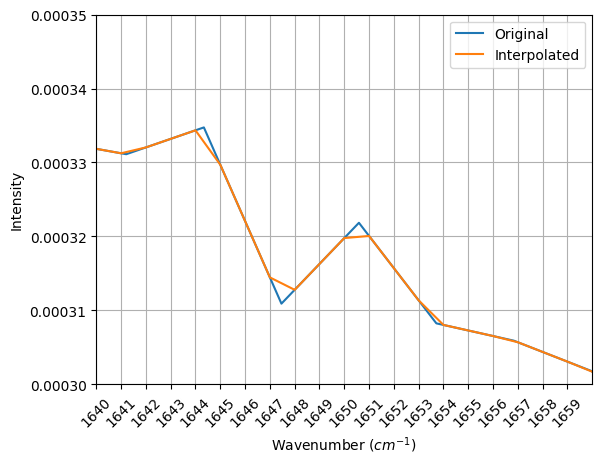

In [281]:
plt.plot(np.array(test_spectral_cols,dtype='float'),original_data,label='Original')
plt.plot(fingerprint_grid,new_data,label = 'Interpolated')
wn_range = (1640,1660)
plt.xlim(wn_range[0],wn_range[1])
plt.ylim(0.0003,0.00035)
plt.xticks(np.arange(wn_range[0],wn_range[1],1),rotation=45)
plt.grid()
plt.legend()
plt.xlabel('Wavenumber $(cm^{-1})$')
plt.ylabel('Intensity')
plt.show()

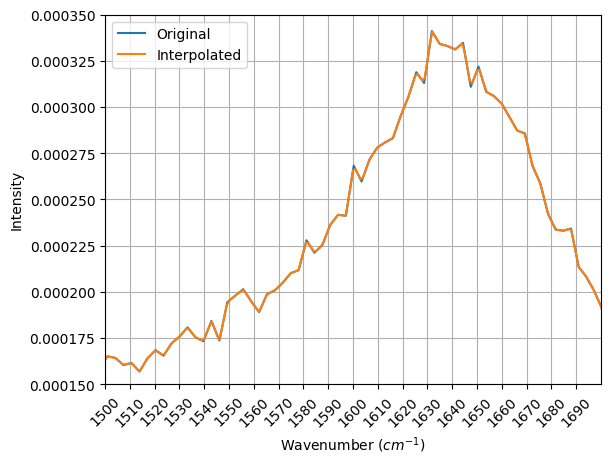

In [282]:
plt.plot(np.array(test_spectral_cols,dtype='float'),original_data,label='Original')
plt.plot(fingerprint_grid,new_data,label = 'Interpolated')
wn_range = (1500,1700)
plt.xlim(wn_range[0],wn_range[1])
plt.ylim(0.00015,0.00035)
plt.xticks(np.arange(wn_range[0],wn_range[1],10),rotation=45)
plt.xlabel('Wavenumber $(cm^{-1})$')
plt.ylabel('Intensity')
plt.grid()
plt.legend()
plt.show()

In [283]:
## Linear interpolation works well even for timegate, the dataset with the most sparse wavenumber columns

In [284]:
## Can np.interpolate handle multiple rows at once?

np.interp(fingerprint_grid,np.array(test_spectral_cols,dtype='float'),test_spectral.iloc[1:3].to_numpy())

ValueError: object too deep for desired array

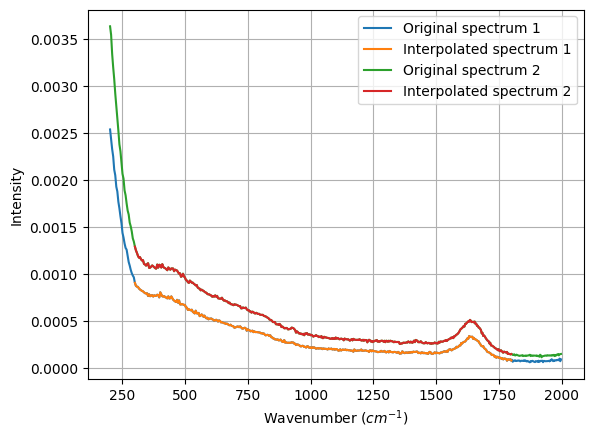

In [ ]:
from scipy.interpolate import interp1d

def interpolate_spectra_to_grid(spectra: np.ndarray, old_wavenumbers: np.ndarray, new_wavenumbers: np.ndarray) -> np.ndarray:
    f = interp1d(
        old_wavenumbers,
        spectra,
        axis=1,
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    return f(new_wavenumbers)

interpolated = interpolate_spectra_to_grid(test_spectral.iloc[:2], np.array(test_spectral_cols,dtype='float'),fingerprint_grid)

plt.plot(np.array(test_spectral_cols,dtype='float'),test_spectral.iloc[0],label='Original spectrum 1')
plt.plot(fingerprint_grid,interpolated[0],label='Interpolated spectrum 1')
plt.plot(np.array(test_spectral_cols,dtype='float'),test_spectral.iloc[1],label='Original spectrum 2')
plt.plot(fingerprint_grid,interpolated[1],label='Interpolated spectrum 2')
plt.grid()
plt.legend()
plt.xlabel('Wavenumber $(cm^{-1})$')
plt.ylabel('Intensity')
plt.show()


## np interpolation can't handle multiple rows at once, but the scipy one can.

In [ ]:
from dig4bio.preprocessing import interpolate_spectra_to_grid

interpolated_by_device = {}

for device, df in interim_dfs.items():
    spectral_cols = get_interim_spectral_cols(device,df)

    old_wavenumbers = np.array(spectral_cols, dtype=float)
    spectra = df[spectral_cols].to_numpy(dtype=float)
    
    interpolated_by_device[device] = interpolate_spectra_to_grid(spectra,old_wavenumbers=old_wavenumbers)

In [ ]:
from dig4bio.constants import FINGERPRINT_GRID
old_96_spectrum_df = interim_dfs['96_samples'][get_interim_spectral_cols('96_samples',interim_dfs['96_samples'])]
display(pd.DataFrame(interpolated_by_device['96_samples'],columns = FINGERPRINT_GRID.astype(str)))
display(old_96_spectrum_df[old_96_spectrum_df.columns[147:]])

,300,301,302,303,304,305,306,307,308,309,...,1790,1791,1792,1793,1794,1795,1796,1797,1798,1799
0,9459.1250,9440.062112,9440.683230,9403.02500,9325.52500,9295.440994,9269.600,9239.6,9269.279503,9315.65000,...,1619.689441,1627.53125,1642.844720,1642.223602,1645.2,1650.819876,1671.316770,1689.71875,1705.34375,1696.142857
1,9441.6250,9411.422360,9435.645963,9429.93125,9393.05625,9312.714286,9256.075,9274.2,9299.850932,9323.63125,...,1632.900621,1640.06250,1653.049689,1641.248447,1644.2,1655.919255,1678.900621,1679.10000,1649.10000,1665.136646
2,8607.1875,8614.714286,8571.857143,8517.23125,8450.35625,8408.726708,8371.900,8339.4,8352.229814,8381.90000,...,1562.204969,1594.09375,1625.701863,1596.509317,1592.4,1603.565217,1642.695652,1666.07500,1668.57500,1651.987578
3,8560.0625,8553.944099,8543.385093,8527.58750,8506.33750,8434.900621,8377.950,8374.2,8410.590062,8458.28125,...,1584.571429,1602.03125,1623.291925,1616.459627,1612.0,1609.695652,1627.086957,1630.55000,1615.55000,1632.074534
4,9432.6875,9347.453416,9321.987578,9321.55625,9347.18125,9274.819876,9216.275,9224.4,9251.919255,9279.65625,...,1602.720497,1616.68750,1639.360248,1628.801242,1645.4,1677.118012,1705.068323,1704.33750,1665.58750,1693.024845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,9424.8750,9449.583851,9415.422360,9380.85000,9345.85000,9276.770186,9215.950,9187.2,9226.993789,9288.96875,...,1591.925466,1610.28125,1633.428571,1619.142857,1623.6,1638.571429,1652.857143,1652.13125,1631.50625,1642.950311
188,9286.9375,9219.875776,9218.633540,9176.35000,9091.35000,9072.602484,9057.475,9030.6,9054.521739,9094.01250,...,1594.552795,1592.56250,1598.981366,1590.906832,1602.8,1625.894410,1648.254658,1663.95625,1670.83125,1652.925466
189,9425.3750,9358.006211,9348.068323,9301.35000,9216.35000,9203.683230,9197.850,9186.6,9245.931677,9329.59375,...,1598.291925,1607.00000,1620.447205,1614.236025,1622.0,1638.242236,1669.298137,1678.40000,1658.40000,1670.981366
190,9433.0625,9367.043478,9297.478261,9233.82500,9176.32500,9134.068323,9090.300,9037.8,9117.720497,9246.71875,...,1592.552795,1620.84375,1648.080745,1616.403727,1606.2,1609.689441,1651.925466,1668.74375,1651.86875,1650.546584


,300.9,302.51,304.11,305.72,307.32,308.93,310.53,312.14,313.74,315.35,...,3335.56,3337.16,3338.77,3340.37,3341.98,3343.58,3345.19,3346.79,3348.4,3350.0
0,9440,9441,9317,9278,9230,9323,9155,9167,9124,9152,...,1709,1706,1598,1627,1653,1008,1035,1061,1282,5611
1,9409,9448,9389,9251,9280,9327,9250,9152,9191,9121,...,1668,1659,1594,1625,1656,1022,1020,1057,1301,5731
2,8619,8550,8443,8381,8329,8384,8336,8263,8253,8225,...,1650,1617,1544,1558,1617,1012,1012,1059,1295,5112
3,8555,8538,8504,8379,8373,8462,8377,8304,8311,8295,...,1629,1644,1551,1545,1559,1013,1036,1070,1274,5161
4,9350,9309,9350,9214,9227,9286,9141,9143,9124,9130,...,1687,1705,1602,1634,1620,1008,1016,1051,1278,5513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,9453,9398,9342,9224,9178,9294,9179,9073,9071,9057,...,1685,1701,1573,1638,1615,1037,1003,1039,1271,5402
188,9220,9218,9082,9065,9022,9099,8985,8859,8992,8915,...,1658,1690,1569,1585,1640,1001,1007,1043,1260,5863
189,9359,9343,9207,9201,9183,9332,9277,9070,9006,9122,...,1680,1678,1563,1607,1641,984,1002,1044,1241,5601
190,9374,9262,9170,9105,9021,9250,9175,9035,9134,9038,...,1679,1657,1553,1606,1631,994,991,1052,1272,5458
